# 📊 Load Dataset

## 📌 Dataset Source
We directly load the dataset from Kaggle.

## 🔍 Description
The dataset is fetched using Kaggle API / KaggleHub, which allows easy access to large datasets without manual download.

> 💡 Tip: Make sure your Kaggle API key is properly configured before running the code.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ronikdedhia/next-word-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'next-word-prediction' dataset.
Path to dataset files: /kaggle/input/next-word-prediction


## 📁 Getting the File Name

After loading the dataset from Kaggle, we need to identify the file name to read it properly.

### 🔍 Steps:
- Check the dataset directory
- List all available files
- Select the required file for further processing

> 💡 Tip: Use `os.listdir()` or similar methods to view file names inside the dataset folder.


In [4]:
import os

files = os.listdir(path)
print(files)

['1661-0.txt']


## 📄 Preview Dataset (First 500 Characters)

To understand the structure and content of the dataset, we open the text file and display the first 500 characters.

### 🔍 Why this step?
- Helps in quick inspection of data
- Identifies format (sentences, paragraphs, symbols, etc.)
- Useful for planning preprocessing steps

> 💡 Tip: Always preview data before applying preprocessing or training a model.

In [5]:
with open(os.path.join(path, files[0]), 'r', encoding='utf-8') as f:
    text = f.read()

print(text[:500])  # print first 500 characters

﻿
Project Gutenberg's The Adventures of Sherlock Holmes, by Arthur Conan Doyle

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.net


Title: The Adventures of Sherlock Holmes

Author: Arthur Conan Doyle

Release Date: November 29, 2002 [EBook #1661]
Last Updated: May 20, 2019

Language: English

Charac


# 📂 Import Necessary Libraries


In [6]:
import tensorflow as tf
import nltk
nltk.download('punkt')
import re
import string
from nltk.tokenize import sent_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from bs4 import BeautifulSoup

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# 🧹 Text Preprocessing

In this step, we prepare the raw text data for model training by splitting it into sentences and cleaning each sentence.

---

## 🔹 Sentence Splitting

We divide the full text into individual sentences using punctuation marks like `.`, `!`, and `?`.

### 🔍 Why?
- Helps in handling smaller chunks of text  
- Makes it easier to process and train the model  

---

## 🔹 Text Cleaning

Each sentence is cleaned by:
- Converting text to lowercase  
- Removing special characters and numbers  
- Keeping only alphabets  

> 💡 This ensures uniform and noise-free data.

---

## 🔹 Removing Empty Sentences

After cleaning, some sentences may become empty.  
We remove them to avoid issues during training.

---

## 🔹 Output Verification

Finally, we print the cleaned sentences to verify the preprocessing step.

> ✅ Clean data = Better model performance

In [7]:
#  Split into sentences
def split_sentences(text):
    sentences = re.split(r'[.!?]', text)
    return sentences

sentences = split_sentences(text)


#  Clean each sentence
def clean_text(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r'[^a-zA-Z ]', '', sentence)
    return sentence.strip()


#  Apply cleaning and remove empty sentences
clean_sentences = []

for s in sentences:
    cleaned = clean_text(s)

    if cleaned != "":
        clean_sentences.append(cleaned)


#  Check output
print("\nCleaned Sentences:\n")
print(clean_sentences[:])


Cleaned Sentences:

['project gutenbergs the adventures of sherlock holmes by arthur conan doylethis ebook is for the use of anyone anywhere at no cost and withalmost no restrictions whatsoever', 'you may copy it give it away orreuse it under the terms of the project gutenberg license includedwith this ebook or online at www', 'gutenberg', 'nettitle the adventures of sherlock holmesauthor arthur conan doylerelease date november   ebook last updated may  language englishcharacter set encoding utf start of this project gutenberg ebook the adventures of sherlock holmes produced by an anonymous project gutenberg volunteer and jose menendezcoverthe adventures of sherlock holmesby arthur conan doylecontents   i', 'a scandal in bohemia   ii', 'the redheaded league   iii', 'a case of identity   iv', 'the boscombe valley mystery   v', 'the five orange pips   vi', 'the man with the twisted lip   vii', 'the adventure of the blue carbuncle   viii', 'the adventure of the speckled band   ix', 'the 

# 🔤 Tokenization and Vocabulary Building

In this step, we convert text data into numerical form so that it can be used by the model.

---

## 🔹 Preparing Text Data

We select a subset of cleaned sentences to work with (first 5000 sentences).

> 💡 This helps in faster training and reduces memory usage.

---

## 🔹 Tokenization

We use a tokenizer to:
- Assign a unique number to each word  
- Convert text into sequences of integers  

---

## 🔹 Building Vocabulary

The tokenizer scans all sentences and creates a vocabulary of unique words.

- Each word is mapped to an index  
- This mapping is stored in `word_index`

---

## 🔹 Output Verification

We print the word index to see how words are converted into numbers.

> ✅ This is an important step for feeding data into neural networks

In [8]:
text = clean_sentences[:5000]
tokenizer = Tokenizer()

# build vocabulary
tokenizer.fit_on_texts(text)
print(tokenizer.word_index)

{'the': 1, 'and': 2, 'i': 3, 'of': 4, 'a': 5, 'to': 6, 'in': 7, 'it': 8, 'that': 9, 'he': 10, 'you': 11, 'was': 12, 'his': 13, 'is': 14, 'my': 15, 'have': 16, 'as': 17, 'with': 18, 'had': 19, 'which': 20, 'for': 21, 'at': 22, 'but': 23, 'not': 24, 'me': 25, 'be': 26, 'we': 27, 'holmes': 28, 'there': 29, 'said': 30, 'from': 31, 'upon': 32, 'this': 33, 'him': 34, 'so': 35, 'what': 36, 'on': 37, 'no': 38, 'one': 39, 'then': 40, 'been': 41, 'by': 42, 'your': 43, 'very': 44, 'all': 45, 'are': 46, 'were': 47, 'she': 48, 'her': 49, 'an': 50, 'man': 51, 'would': 52, 'out': 53, 'when': 54, 'mr': 55, 'do': 56, 'up': 57, 'has': 58, 'into': 59, 'who': 60, 'if': 61, 'will': 62, 'some': 63, 'see': 64, 'now': 65, 'could': 66, 'little': 67, 'down': 68, 'well': 69, 'or': 70, 'us': 71, 'may': 72, 'am': 73, 'know': 74, 'our': 75, 'shall': 76, 'about': 77, 'come': 78, 'they': 79, 'must': 80, 'can': 81, 'did': 82, 'over': 83, 'more': 84, 'than': 85, 'two': 86, 'time': 87, 'before': 88, 'how': 89, 'should':

# 🔢 Text to Sequences Conversion

In this step, we convert the text data into sequences of integers using the fitted tokenizer.

---

## 🔹 Sequence Generation

Each sentence is transformed into a list of numbers, where:
- Each number represents a specific word  
- The mapping is based on the tokenizer's vocabulary (`word_index`)  

---

## 🔹 Why is this important?

- Machine learning models cannot understand text directly  
- Numerical representation is required for training neural networks  

---

## 🔹 Output Verification

We print the first few sequences to understand how sentences are converted into numerical format.

> 💡 Example:  
> "hello world" → [12, 45]

> ✅ These sequences will be used as input for the LSTM model

In [9]:
sequences = tokenizer.texts_to_sequences(text)

print(sequences[:5])

[[1373, 3507, 1, 852, 4, 101, 28, 42, 1721, 1722, 3508, 1374, 14, 21, 1, 266, 4, 463, 2294, 22, 38, 1723, 2, 3509, 38, 3510, 3511], [11, 72, 1724, 8, 204, 8, 132, 3512, 8, 339, 1, 1725, 4, 1, 1373, 1375, 2295, 3513, 33, 1374, 70, 3514, 22, 3515], [1375], [3516, 1, 852, 4, 101, 3517, 1721, 1722, 3518, 853, 3519, 1374, 129, 3520, 72, 2296, 3521, 315, 3522, 3523, 690, 4, 33, 1373, 1375, 1374, 1, 852, 4, 101, 28, 1726, 42, 50, 3524, 1373, 1375, 3525, 2, 3526, 3527, 852, 4, 101, 3528, 1721, 1722, 3529, 3], [5, 854, 7, 855, 1727]]


# 🔢 Vocabulary Size

We calculate the total number of unique words in the dataset.

- `word_index` stores all unique words  
- We add `1` to account for padding or indexing  

> ✅ This value is used to define the model’s input dimension

In [10]:
total_words = len(tokenizer.word_index) + 1
print("Total words:", total_words)

Total words: 10062


# 🔗 N-gram Sequence Creation

We generate input sequences using the n-gram technique.

- Each sequence contains a partial sentence  
- Used to predict the next word  

> 💡 Example:  
> [1, 2, 3] → [1, 2], [1, 2, 3]

> ✅ These sequences are used for training the model

In [11]:
input_sequences = []

for seq in sequences:
    for i in range(1, len(seq)):
        n_gram = seq[:i+1]
        input_sequences.append(n_gram)

print(input_sequences[:5])

[[1373, 3507], [1373, 3507, 1], [1373, 3507, 1, 852], [1373, 3507, 1, 852, 4], [1373, 3507, 1, 852, 4, 101]]


In [12]:
# get the maximum length sequence
max_len = max([len(x) for x in input_sequences])
max_len

93

# 📏 Sequence Padding

We apply padding to make all input sequences of equal length.

- Shorter sequences are padded with zeros  
- Padding is added at the beginning (`pre`)  

> 💡 This ensures uniform input size for the LSTM model  

> ✅ Required for efficient model training

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_input_sequences = pad_sequences(input_sequences, maxlen = max_len, padding='pre')
padded_input_sequences

array([[   0,    0,    0, ...,    0, 1373, 3507],
       [   0,    0,    0, ..., 1373, 3507,    1],
       [   0,    0,    0, ..., 3507,    1,  852],
       ...,
       [   0,    0,    0, ...,  318,  174,   29],
       [   0,    0,    0, ...,  174,   29,   88],
       [   0,    0,    0, ...,   29,   88, 3326]], dtype=int32)

# 🎯 Input-Output Split

We split the padded sequences into input (X) and output (y).

- `X` → all words except the last word  
- `y` → the last word (target to predict)  

> 💡 The model learns to predict the next word based on input sequence  

> ✅ This is essential for training the prediction model

In [14]:
X = padded_input_sequences[:,:-1]
y = padded_input_sequences[:,-1]
X.shape
y.shape

(61607,)

# 🔢 One-Hot Encoding of Output

We convert the output variable `y` into one-hot encoded format.

- Each word is represented as a vector  
- Only the correct word index is `1`, others are `0`  

> 💡 `num_classes` = total vocabulary size  

> ✅ Required for multi-class classification in neural networks

In [15]:
from tensorflow.keras.utils import to_categorical
y = to_categorical(y,num_classes=13335)
y.shape

(61607, 13335)

# 🧠 Model Architecture

We build a Sequential model for next word prediction.

- **Embedding Layer** → Converts word indices into dense vectors  
- **RNN/LSTM/GRU Layer** → Learns sequence patterns and context  
- **Dense Layer** → Outputs probability for each word using softmax  

> 💡 Softmax gives probability distribution over all words  



In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# ⚠️ Note on Running the Code

The code cell has been converted into Markdown for better readability.  
You can convert it back to a code cell and run it.

> 💡 Shortcut Keys:
- `Ctrl + M + M` → Convert code cell to Markdown  
- `Ctrl + M + Y` → Convert Markdown cell to code  

---

## ⏳ Training Time Warning

The full experimentation loop takes a long time to train because it runs multiple models with different configurations.

👉 For quick testing:
- Use fewer models  
- Reduce number of layers  
- Train only selected configurations  

> ✅ In this project, we trained a subset of models to save time and resources.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adagrad
from tensorflow.keras import backend as K


models_config = [
    ("RNN", SimpleRNN),
    ("LSTM", LSTM),
    ("GRU", GRU)
]

optimizers = {
    "adam": Adam,
    "rmsprop": RMSprop,
    "sgd": SGD,
    "adagrad": Adagrad
}

dropouts = [0.2, 0.3]
layers_options = [1, 2, 3]
bidirectional_options = [True, False]

results = []

for model_name, layer_type in models_config:
    for opt_name, opt_class in optimizers.items():
        for dropout_rate in dropouts:
            for num_layers in layers_options:
                for use_bidir in bidirectional_options:

                    print(f"\nModel: {model_name}, Layers={num_layers}, Dropout={dropout_rate}, Opt={opt_name}, Bidir={use_bidir}")

                    K.clear_session()
                    optimizer = opt_class()

                    model = Sequential()
                    model.add(Embedding(13335, 100))

                    #  Layer building
                    if num_layers == 1:
                        if use_bidir:
                            model.add(Bidirectional(layer_type(150)))
                        else:
                            model.add(layer_type(150))
                    else:
                        # first layer
                        if use_bidir:
                            model.add(Bidirectional(layer_type(150, return_sequences=True)))
                        else:
                            model.add(layer_type(150, return_sequences=True))

                        # middle layers
                        for _ in range(num_layers - 2):
                            model.add(layer_type(120, return_sequences=True))

                        # last layer
                        model.add(layer_type(100))

                    # dropout
                    model.add(Dropout(dropout_rate))

                    # dense layer
                    model.add(Dense(128, activation='relu'))

                    # output layer
                    model.add(Dense(13335, activation='softmax'))

                    model.compile(
                        loss='categorical_crossentropy',
                        optimizer=optimizer,
                        metrics=['accuracy']
                    )

                    history = model.fit(X, y, epochs=100, batch_size=128, verbose=0)

                    acc = history.history['accuracy'][-1]

                    results.append({
                        "model": model_name,
                        "layers": num_layers,
                        "bidirectional": use_bidir,
                        "dropout": dropout_rate,
                        "optimizer": opt_name,
                        "accuracy": acc
                    })

print("\nFinal Results:\n")
for r in results:
    print(r)

# 🧠 Model Training and Comparison

In this section, we train and compare three different models:

- **LSTM** → Baseline model for sequence learning  
- **Bidirectional LSTM** → Captures context from both directions  
- **GRU** → Faster and efficient alternative to LSTM  

---

## 🔹 Training Strategy

- All models are trained using the same dataset  
- Same hyperparameters are used for fair comparison  
- Accuracy is recorded for each model  

> 💡 This ensures a consistent and unbiased evaluation

---

## 🔹 Model Evaluation

After training:
- We compare the accuracy of all models  
- Identify the best-performing model  

> ✅ The model with highest accuracy is selected as the final model

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, Bidirectional
from tensorflow.keras import backend as K

models = {
    "LSTM": lambda: Sequential([
        Embedding(13335, 100),
        LSTM(150),
        Dense(13335, activation='softmax')
    ]),

    "BiLSTM": lambda: Sequential([
        Embedding(13335, 100),
        Bidirectional(LSTM(150)),
        Dense(13335, activation='softmax')
    ]),

    "GRU": lambda: Sequential([
        Embedding(13335, 100),
        GRU(150),
        Dense(13335, activation='softmax')
    ])
}

results = []
history_dict = {}   # ✅ store history

for name, build_model in models.items():
    print(f"\nTraining {name} model...")

    K.clear_session()
    model = build_model()

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )


    history = model.fit(X, y, epochs=5, batch_size=128, verbose=0)

    # ✅ store full history
    history_dict[name] = history.history

    # final accuracy
    acc = history.history['accuracy'][-1]

    results.append((name, acc))

# ✅ Print results
print("\nFinal Results:")
for model_name, acc in results:
    print(f"{model_name}: {acc}")


Training LSTM model...

Training BiLSTM model...

Training GRU model...

Final Results:
LSTM: 0.1274368166923523
BiLSTM: 0.13990293443202972
GRU: 0.14035741984844208


Here i have used only 5 epoches. That's why accuracy is so low if you increse the epoches accuracy will increase

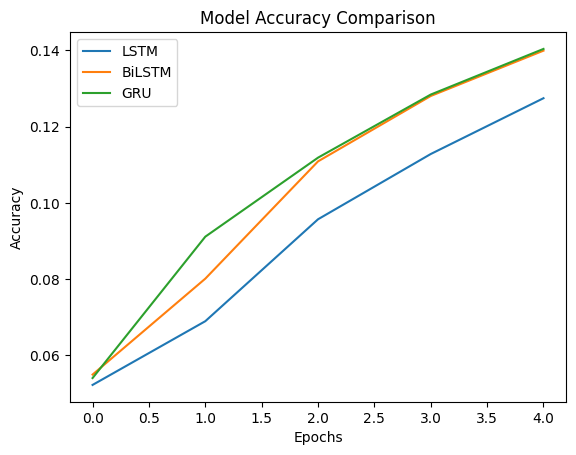

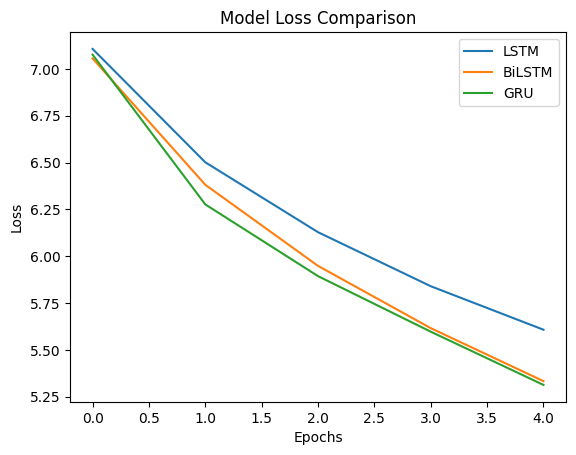

In [18]:
import matplotlib.pyplot as plt

# 📊 Accuracy Plot
plt.figure()

for name, history in history_dict.items():
    plt.plot(history['accuracy'], label=name)

plt.title("Model Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# 📉 Loss Plot
plt.figure()

for name, history in history_dict.items():
    plt.plot(history['loss'], label=name)

plt.title("Model Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_next_word(model, tokenizer, text, max_len):

    # convert input text to sequence
    token_list = tokenizer.texts_to_sequences([text])[0]

    # pad sequence
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

    # predict next word
    predicted = model.predict(token_list, verbose=0)
    predicted_index = np.argmax(predicted, axis=1)[0]

    # convert index to word
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            return word

    return ""

In [20]:
def generate_text(model, tokenizer, seed_text, max_len, num_words):

    for _ in range(num_words):
        next_word = predict_next_word(model, tokenizer, seed_text, max_len)
        seed_text += " " + next_word

    return seed_text

In [22]:
print(generate_text(model, tokenizer, "I have been ", max_len, 5))

I have been  a little man and i
